In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("Complaints_data.xlsx")

print(df.head())
print(df.info())

        Date  Complaints days 
0 2026-03-02         129   mon
1 2026-03-03         171   tue
2 2026-03-04          61   wed
3 2026-03-05         138   thu
4 2026-03-06         165   fri
<class 'pandas.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        127 non-null    datetime64[us]
 1   Complaints  127 non-null    int64         
 2   days        127 non-null    str           
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 3.1 KB
None


Cleaning the data

In [2]:
# Make a copy
data = df.copy()

# Remove unnecessary spaces from column names
data.columns = data.columns.str.strip()

# Convert Date to datetime
data["Date"] = pd.to_datetime(data["Date"])

# Sort by date
data = data.sort_values("Date")

# Remove duplicate dates if any
data = data.drop_duplicates(subset="Date")

# Set Date as index
data = data.set_index("Date")

print(data.head())
print(data.tail())

            Complaints days
Date                       
2026-03-02         129  mon
2026-03-03         171  tue
2026-03-04          61  wed
2026-03-05         138  thu
2026-03-06         165  fri
            Complaints days
Date                       
2026-07-22         172  wed
2026-07-23         149  thu
2026-07-24          66  fri
2026-07-25         113  sat
2026-07-27         126  mon


check the dataquality

In [ ]:
print("Number of records:", len(data))

print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicate dates:")
print(data.index.duplicated().sum())

print("\nDate range:")
print(data.index.min(), "to", data.index.max())

print("\nBasic statistics:")
print(data["Complaints"].describe())

In [ ]:
data["Weekday"] = data.index.day_name()

print(data["Weekday"].value_counts())

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(data.index, data["Complaints"])

plt.title("Daily Overdraft Complaints")
plt.xlabel("Date")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

weekday_avg = (
    data.groupby("Weekday")["Complaints"]
    .mean()
    .reindex(weekday_order)
)

print(weekday_avg)

In [ ]:
plt.figure(figsize=(10, 5))

weekday_avg.plot(kind="bar")

plt.title("Average Complaints by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Complaints")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
monthly = data["Complaints"].resample("ME").agg(
    ["sum", "mean", "count"]
)

print(monthly)

Forecasting the next 6 months

Because the data contains complaints for Monday to Friday, the forecast is generated for future weekdays only. The last 20% of observations is held out as a test set so forecast accuracy is measured on dates the model did not see during training.

Training observations: 85
Test observations: 21

Accuracy on the unseen test period (lower is better):
                            MAE   RMSE  MAPE (%)
Weekly seasonal baseline  57.29  70.61     69.09
Random Forest             37.19  43.69     44.80

Selected model: Random Forest


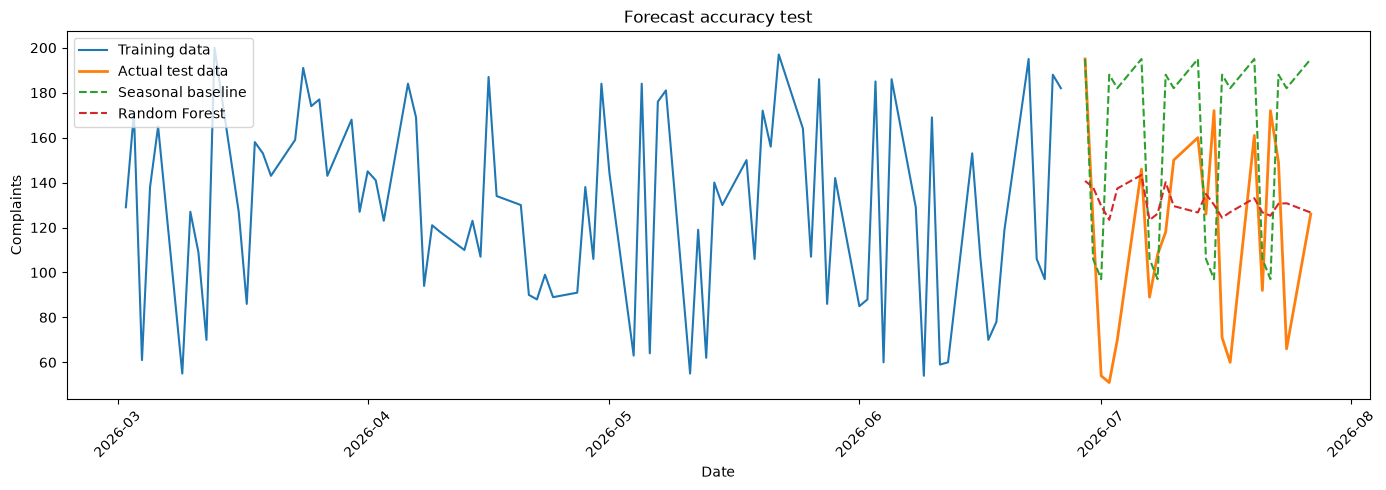

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Keep only the Monday-to-Friday reporting days.
series = data.loc[data.index.dayofweek < 5, "Complaints"].astype(float).sort_index()

# Keep the final 20% completely unseen for accuracy testing.
test_size = max(5, int(len(series) * 0.20))
train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

# A seasonal-naive forecast repeats the value from the same weekday last week.
def seasonal_naive(history, steps, season_length=5):
    history = list(history)
    return np.array([history[-season_length + i % season_length] for i in range(steps)])

baseline_predictions = seasonal_naive(train, len(test))

# Create lag features using the previous five weekdays and a short rolling mean.
def make_features(values):
    values = pd.Series(values)
    features = pd.DataFrame(index=values.index)
    for lag in range(1, 6):
        features[f"lag_{lag}"] = values.shift(lag)
    features["rolling_mean_5"] = values.shift(1).rolling(5).mean()
    return features

max_lag = 5
train_features = make_features(train).iloc[max_lag:]
train_target = train.iloc[max_lag:]

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42,
)
model.fit(train_features, train_target)

# Predict one weekday at a time so each prediction can feed the next one.
def recursive_forecast(history, steps, fitted_model):
    history = list(history)
    predictions = []
    for _ in range(steps):
        features = make_features(pd.Series(history)).iloc[[-1]]
        prediction = float(fitted_model.predict(features)[0])
        predictions.append(prediction)
        history.append(prediction)
    return np.array(predictions)

model_predictions = recursive_forecast(train, len(test), model)

def accuracy(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "MAPE (%)": np.mean(np.abs((actual - predicted) / actual)) * 100,
    }

results = pd.DataFrame(
    [accuracy(test, baseline_predictions), accuracy(test, model_predictions)],
    index=["Weekly seasonal baseline", "Random Forest"],
).round(2)
print(f"Training observations: {len(train)}")
print(f"Test observations: {len(test)}")
print("\nAccuracy on the unseen test period (lower is better):")
print(results)

best_model_name = results["RMSE"].idxmin()
print(f"\nSelected model: {best_model_name}")

plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label="Training data")
plt.plot(test.index, test, label="Actual test data", linewidth=2)
plt.plot(test.index, baseline_predictions, label="Seasonal baseline", linestyle="--")
plt.plot(test.index, model_predictions, label="Random Forest", linestyle="--")
plt.title("Forecast accuracy test")
plt.xlabel("Date")
plt.ylabel("Complaints")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Model comparison on the same unseen test period (lower is better):
                            MAE   RMSE  MAPE (%)
Weekly seasonal baseline  57.29  70.61     69.09
Random Forest             37.19  43.69     44.80
ARIMA(1,0,1)              38.02  44.84     45.25

Best fit by RMSE: Random Forest


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


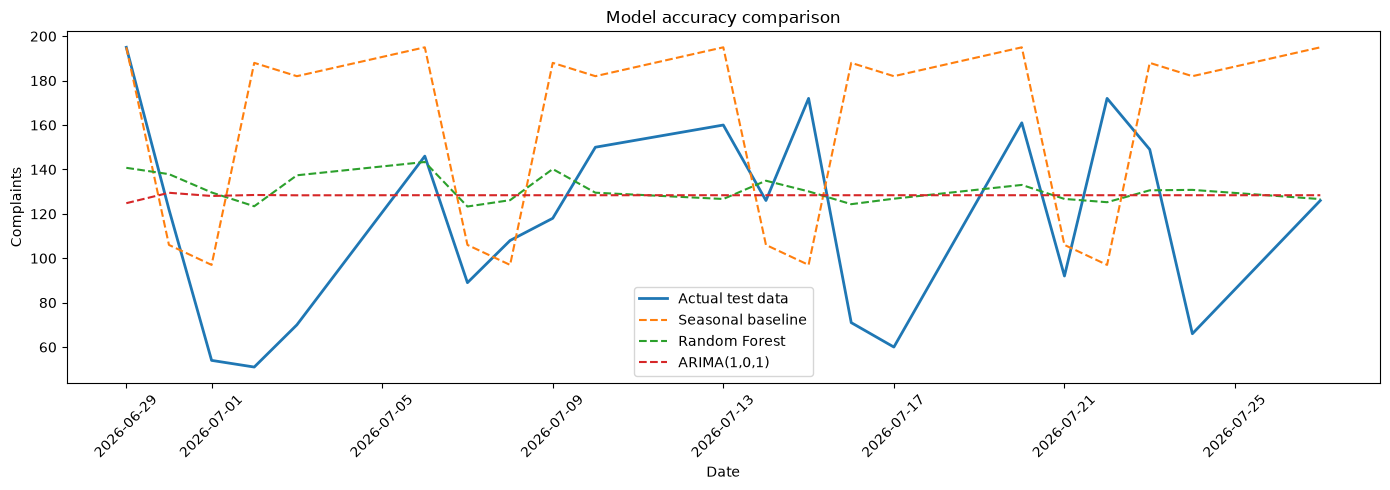

In [4]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(1, 0, 1) models short-term dependence in the weekday complaint series.
arima = ARIMA(train, order=(1, 0, 1), enforce_stationarity=False, enforce_invertibility=False)
arima_fit = arima.fit()
arima_predictions = arima_fit.forecast(steps=len(test)).to_numpy()

arima_accuracy = pd.DataFrame(
    [accuracy(test, arima_predictions)],
    index=["ARIMA(1,0,1)"],
).round(2)
results = pd.concat([results, arima_accuracy])

print("\nModel comparison on the same unseen test period (lower is better):")
print(results)

best_model_name = results["RMSE"].idxmin()
print(f"\nBest fit by RMSE: {best_model_name}")

plt.figure(figsize=(14, 5))
plt.plot(test.index, test, label="Actual test data", linewidth=2)
plt.plot(test.index, baseline_predictions, label="Seasonal baseline", linestyle="--")
plt.plot(test.index, model_predictions, label="Random Forest", linestyle="--")
plt.plot(test.index, arima_predictions, label="ARIMA(1,0,1)", linestyle="--")
plt.title("Model accuracy comparison")
plt.xlabel("Date")
plt.ylabel("Complaints")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Six-month forecast

The selected model is retrained on all available Monday–Friday observations before forecasting each future weekday for six calendar months.

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


Selected model: Random Forest
Forecast period: 2026-07-28 to 2027-01-27
Weekdays forecast: 132

First 10 forecasted weekdays:
            Forecasted complaints
Date                             
2026-07-28                    147
2026-07-29                     87
2026-07-30                    128
2026-07-31                    155
2026-08-03                    127
2026-08-04                    125
2026-08-05                    147
2026-08-06                    142
2026-08-07                    136
2026-08-10                    146

Forecast summary:
count    132.00
mean     146.28
std       13.64
min       87.00
25%      140.00
50%      149.00
75%      156.00
max      163.00
Name: Forecasted complaints, dtype: float64


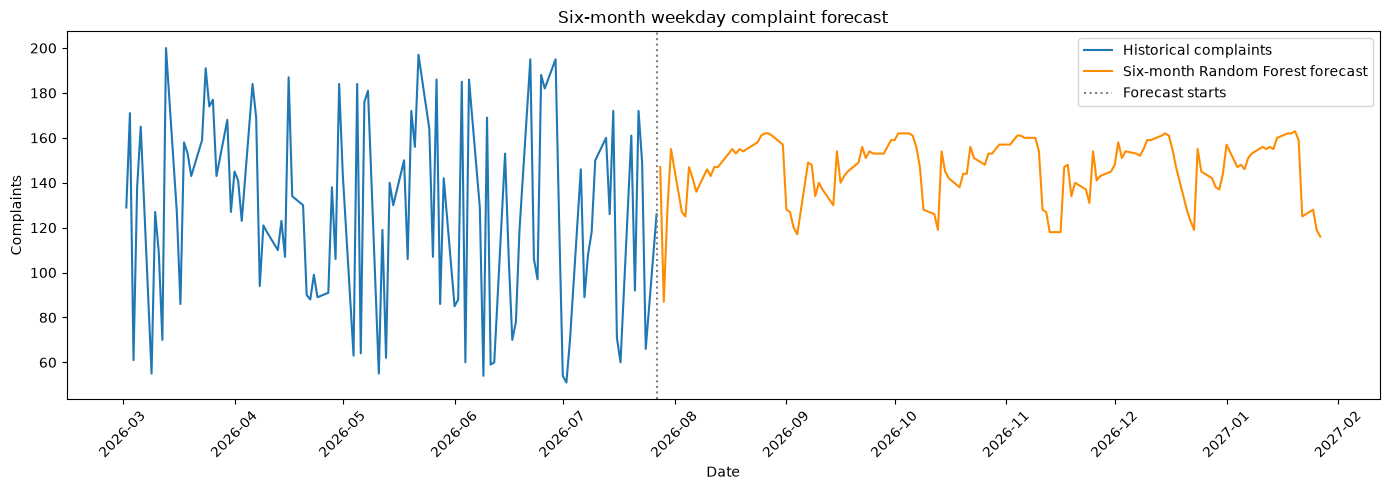

In [5]:
# Refit the candidate models using every available Monday-to-Friday observation.
all_features = make_features(series).iloc[max_lag:]
all_target = series.iloc[max_lag:]
full_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42,
)
full_model.fit(all_features, all_target)

full_arima_fit = ARIMA(
    series,
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit()

last_date = series.index.max()
forecast_end = last_date + pd.DateOffset(months=6)
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    end=forecast_end,
    freq="B",
)

if best_model_name == "Random Forest":
    future_values = recursive_forecast(series, len(future_dates), full_model)
elif best_model_name == "ARIMA(1,0,1)":
    future_values = full_arima_fit.forecast(steps=len(future_dates)).to_numpy()
else:
    future_values = seasonal_naive(series, len(future_dates))

forecast = pd.DataFrame(
    {"Forecasted complaints": np.round(future_values).astype(int)},
    index=future_dates,
)
forecast.index.name = "Date"

print(f"Selected model: {best_model_name}")
print(f"Forecast period: {forecast.index.min().date()} to {forecast.index.max().date()}")
print(f"Weekdays forecast: {len(forecast)}")
print("\nFirst 10 forecasted weekdays:")
print(forecast.head(10))
print("\nForecast summary:")
print(forecast["Forecasted complaints"].describe().round(2))

plt.figure(figsize=(14, 5))
plt.plot(series.index, series, label="Historical complaints")
plt.plot(forecast.index, forecast["Forecasted complaints"], label=f"Six-month {best_model_name} forecast", color="darkorange")
plt.axvline(last_date, color="gray", linestyle=":", label="Forecast starts")
plt.title("Six-month weekday complaint forecast")
plt.xlabel("Date")
plt.ylabel("Complaints")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()